## Stress, Smoking, and Heart Disease: Unmasking the Collider Trap

True Causal Effect (Stress -> Heart Disease): 0.00
Marginal Regression Coefficient (Unconditional): -0.0133
Conditional Regression Coefficient (Controlled for Smoking): -0.5479


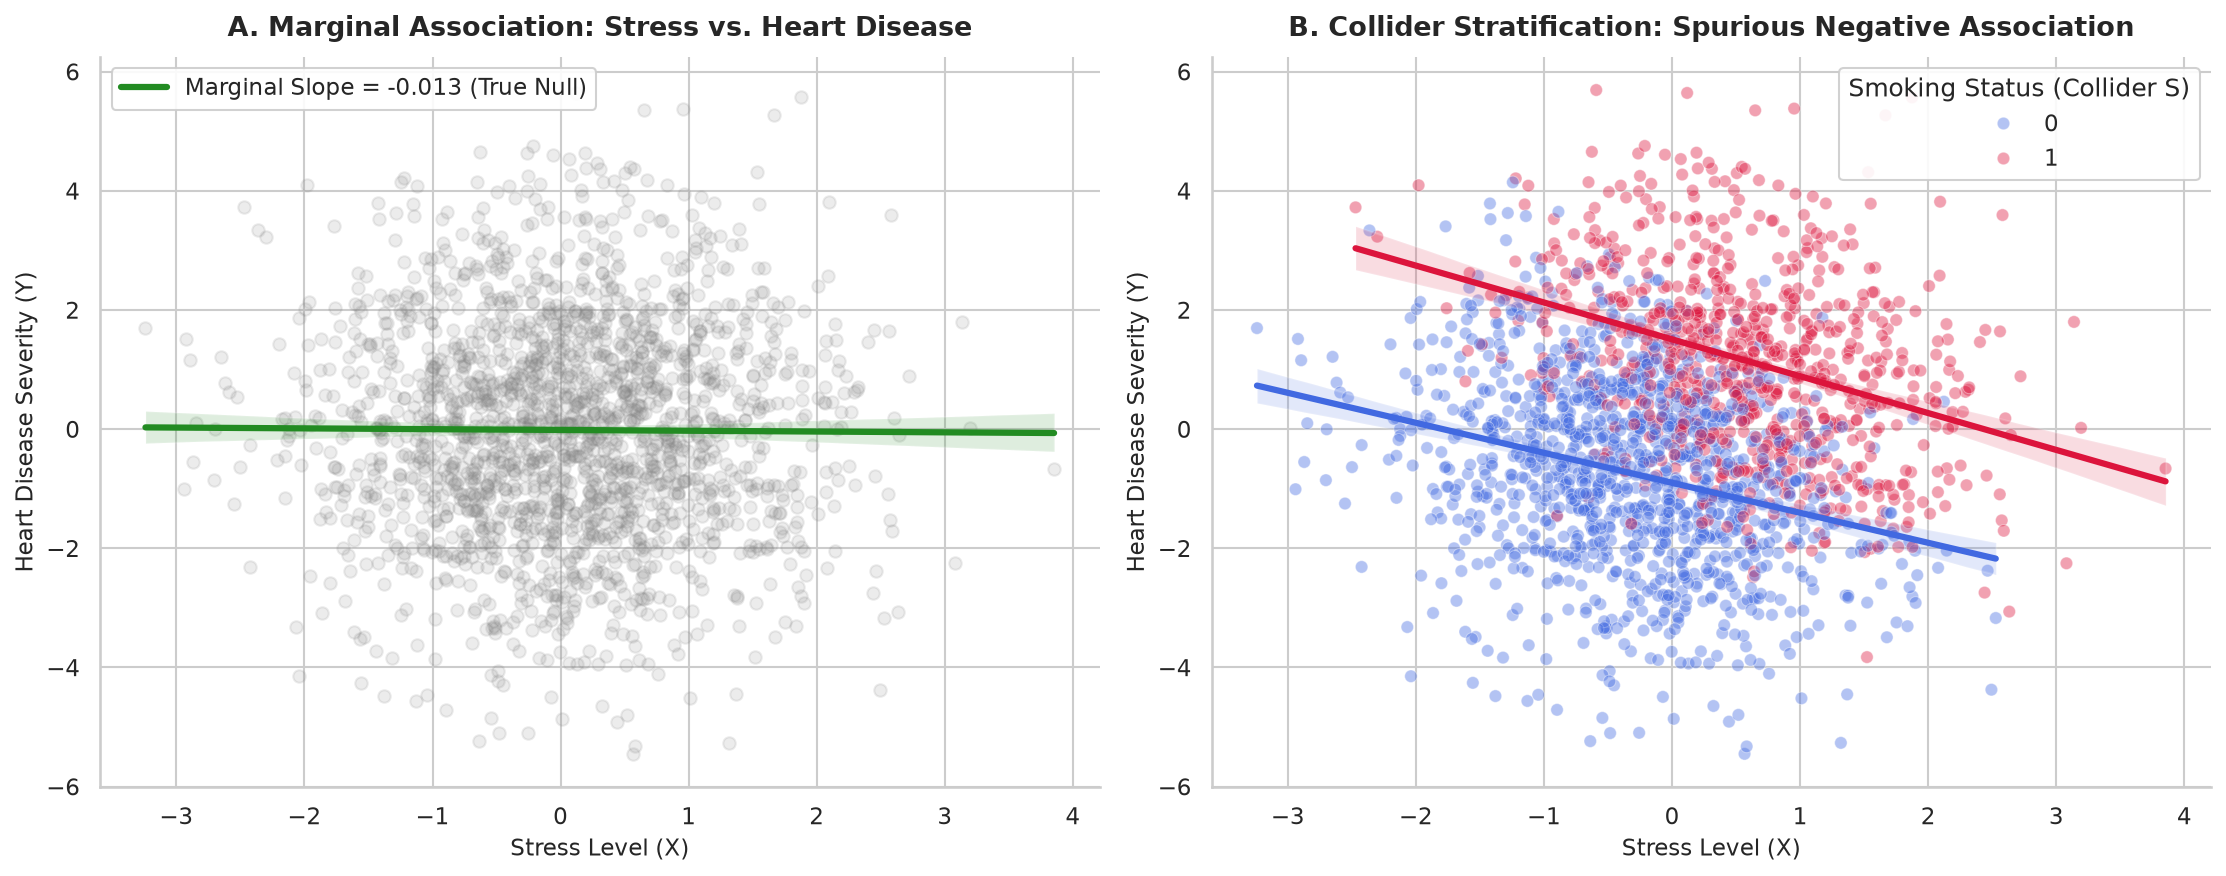

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# Set plotting style
sns.set_theme(style='whitegrid', palette='colorblind', font='DejaVu Sans')
plt.rcParams['figure.dpi'] = 150


# 1. Simulate the Stress-Smoking-Heart Disease Collider System (N=2000)

np.random.seed(42)
N = 2000

# Feature X: Stress level (e.g., occupational stress, continuous)
Stress = np.random.normal(0, 1, N)

# Latent Factor U: Unobserved risk factor (anxiety/addictive predisposition)
U_latent = np.random.normal(0, 1, N)

# Collider S: Smoking status (binary)
# Both Stress (X) and Latent factor (U) increase the probability of smoking
smoking_logit = 1.0 * Stress + 1.2 * U_latent + np.random.normal(0, 0.5, N)
# Dichotomize to make it a binary collider (Smoker vs Non-smoker)
Smoking = (smoking_logit > 0.5).astype(int)

# Target Y: Heart Disease severity (continuous)
# Heart disease is caused strictly by the unobserved risk factor U.
# Stress (X) has ZERO direct causal effect on Heart Disease (Y).
Heart_Disease = 1.5 * U_latent + np.random.normal(0, 1, N)

df = pd.DataFrame({
    'Stress': Stress,
    'Heart_Disease': Heart_Disease,
    'Smoking': Smoking,
    'U_latent': U_latent
})


# 2. Run Regressions to Demonstrate Collider Bias

# Model A: Unconditional regression (Marginal Association) - No Bias
model_marginal = LinearRegression()
model_marginal.fit(df[['Stress']], df['Heart_Disease'])
coef_marginal = model_marginal.coef_[0]

# Model B: Conditional regression (Controlling for Collider Smoking) - BIASED
model_conditional = LinearRegression()
model_conditional.fit(df[['Stress', 'Smoking']], df['Heart_Disease'])
coef_conditional = model_conditional.coef_[0]

print(f"True Causal Effect (Stress -> Heart Disease): 0.00")
print(f"Marginal Regression Coefficient (Unconditional): {coef_marginal:.4f}")
print(f"Conditional Regression Coefficient (Controlled for Smoking): {coef_conditional:.4f}")


# 3. Create Publication-Quality Visuals

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Panel A: Marginal Association (Correctly shows No Correlation)
sns.regplot(data=df, x='Stress', y='Heart_Disease', ax=ax1,
            scatter_kws={'alpha': 0.15, 'color': 'gray'},
            line_kws={'color': 'forestgreen', 'linewidth': 3, 'label': f'Marginal Slope = {coef_marginal:.3f} (True Null)'})
ax1.set_title("A. Marginal Association: Stress vs. Heart Disease", fontsize=13, fontweight='bold', pad=10)
ax1.set_xlabel("Stress Level (X)", fontsize=11)
ax1.set_ylabel("Heart Disease Severity (Y)", fontsize=11)
ax1.legend(frameon=True, facecolor='white', framealpha=0.9, loc='upper left')

# Panel B: Stratification by Collider Smoking (Spurious Negative Correlation)
sns.scatterplot(data=df, x='Stress', y='Heart_Disease', hue='Smoking', palette=['royalblue', 'crimson'], alpha=0.4, ax=ax2)

df_nonsmokers = df[df['Smoking'] == 0]
df_smokers = df[df['Smoking'] == 1]

# Plot separate slopes
sns.regplot(data=df_nonsmokers, x='Stress', y='Heart_Disease', scatter=False, ax=ax2,
            line_kws={'color': 'royalblue', 'linewidth': 3, 
                     'label': f'Non-Smokers (Slope = {LinearRegression().fit(df_nonsmokers[["Stress"]], df_nonsmokers["Heart_Disease"]).coef_[0]:.3f})'})
sns.regplot(data=df_smokers, x='Stress', y='Heart_Disease', scatter=False, ax=ax2,
            line_kws={'color': 'crimson', 'linewidth': 3, 
                     'label': f'Smokers (Slope = {LinearRegression().fit(df_smokers[["Stress"]], df_smokers["Heart_Disease"]).coef_[0]:.3f})'})

ax2.set_title("B. Collider Stratification: Spurious Negative Association", fontsize=13, fontweight='bold', pad=10)
ax2.set_xlabel("Stress Level (X)", fontsize=11)
ax2.set_ylabel("Heart Disease Severity (Y)", fontsize=11)
ax2.legend(title="Smoking Status (Collider S)", frameon=True, facecolor='white', framealpha=0.9, loc='upper right')

sns.despine()
plt.tight_layout()
plt.show()